In [1]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.runtime import build_dataset, build_loader, load_defaults

In [2]:
CONFIG_PATH = ROOT / "config" / "vae.yaml"
BATCH_SIZE = 4

In [3]:
args = Namespace(**load_defaults(CONFIG_PATH))
args.data_dir = ROOT / args.data_dir
args.batch_size = BATCH_SIZE

dataset = build_dataset(args)
batch, phase_fractions = next(
    build_loader(dataset, args, device=torch.device("cpu"))
)

mean_phase_fractions = phase_fractions.mean(dim=0)
print(f"samples: {len(dataset)} | batch: {tuple(batch.shape)}")
print(
    "mean phase fractions:",
    [round(value, 4) for value in mean_phase_fractions.tolist()],
)

samples: 2240 | batch: (4, 1, 64, 64)
mean phase fractions: [0.6024, 0.1047, 0.2929]


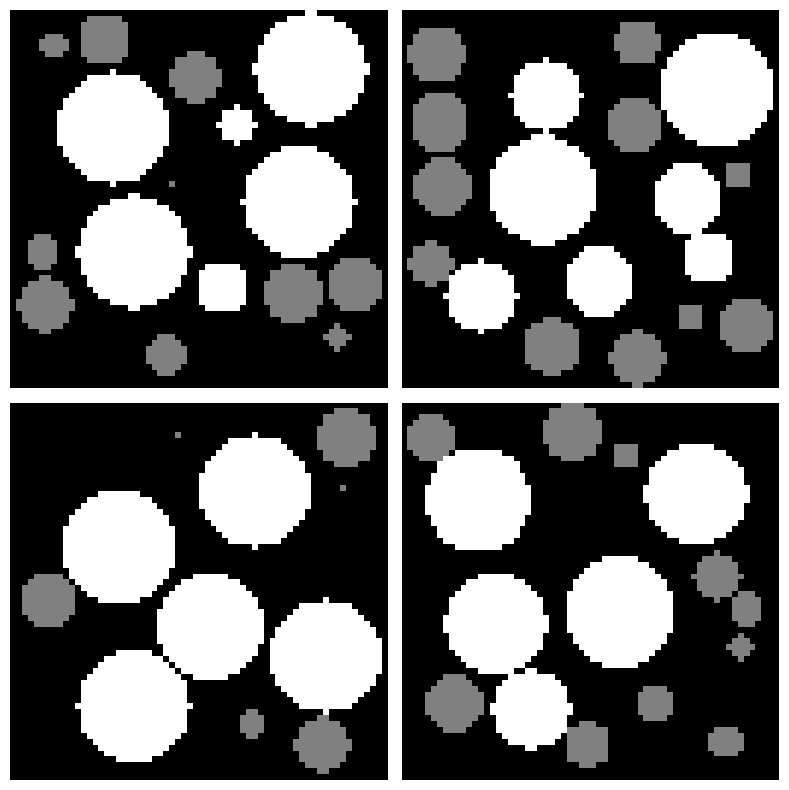

In [4]:
n = min(4, batch.shape[0])
fig, axes = plt.subplots(2, 2, figsize=(8, 8), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for ax, image in zip(axes.ravel(), batch[:n, 0]):
    ax.imshow(image, cmap="gray", vmin=0, vmax=args.num_phases - 1, interpolation="nearest")
plt.tight_layout()